# 1. Introduction

## Evaluation of CIFAR2020 Results

**Objective:**
Compare locally reproduced α,β-CROWN verification results against the official VNN-COMP CIFAR2020 benchmark to evaluate reproducibility, agreement, runtime performance, and causes of divergence.

**Key Metrics:**
- **Verification Agreement:** Percentage of properties where local and official results match.
- **Confusion Matrix:** Cross-tabulation of verification outcomes (SAT, UNSAT, TIMEOUT).
- **Runtime Performance:** Relative execution speed and runtime differences.
- **Disagreement & Solved Breakdown:** Detailed analysis of timeout and mismatch cases.

# 2. Setup & Data Loading

Import required libraries, set display options, define the result normalization helper, and load official and local benchmark datasets.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load datasets
official = pd.read_csv("../data/official/cifar2020.csv")
local = pd.read_csv("../data/experiments/csv/cifar2020.csv")

print(f"Official instances loaded: {len(official)}")
print(f"Local instances loaded   : {len(local)}")

Official instances loaded: 147
Local instances loaded   : 147


# 3. Data Validation

Verify dataset integrity (checking row counts, missing values, duplicates, and network/specification alignment) before performing comparisons.

In [36]:
key_cols = ["benchmark", "onnx_path", "vnnlib_path"]
all_cols = key_cols + ["total_time", "result", "solver_time"]


assert len(official) == len(local), "Dataset row counts do not match."
assert set(official["onnx_path"]) == set(local["onnx_path"]), "Network sets do not match."
assert set(official["vnnlib_path"]) == set(local["vnnlib_path"]), "Specification sets do not match."

validation_summary = pd.DataFrame({
    "Dataset": ["Official", "Local"],
    "Instances": [len(official), len(local)],
    "Unique Networks": [official["onnx_path"].nunique(), local["onnx_path"].nunique()],
    "Unique Specs": [official["vnnlib_path"].nunique(), local["vnnlib_path"].nunique()],
})
display(validation_summary)

,Dataset,Instances,Unique Networks,Unique Specs
0,Official,147,3,147
1,Local,147,3,147


# 4. Merge Datasets

Merge official and local datasets on property keys (`benchmark`, `onnx_path`, `vnnlib_path`) and normalize verification labels.

In [37]:
comparison = official.merge(
    local,
    on=key_cols,
    suffixes=("_official", "_local"),
    validate="one_to_one",
)


display(comparison[[
    "benchmark", "onnx_path", "vnnlib_path",
    "result_official", "result_local",
    "total_time_official", "total_time_local"
]].head())

,benchmark,onnx_path,vnnlib_path,result_official,result_local,total_time_official,total_time_local
0,cifar2020,./benchmarks/cifar2020/nets/cifar10_2_255_simplified.onnx,./benchmarks/cifar2020/specs/cifar10/cifar10_spec_idx_0_eps_0.00784_n1.vnnlib,SAT,SAT,6.733640,0.675500
1,cifar2020,./benchmarks/cifar2020/nets/cifar10_2_255_simplified.onnx,./benchmarks/cifar2020/specs/cifar10/cifar10_spec_idx_1_eps_0.00784_n1.vnnlib,UNSAT,UNSAT,14.718358,0.972500
2,cifar2020,./benchmarks/cifar2020/nets/cifar10_2_255_simplified.onnx,./benchmarks/cifar2020/specs/cifar10/cifar10_spec_idx_2_eps_0.00784_n1.vnnlib,UNSAT,UNSAT,30.070079,5.944700
3,cifar2020,./benchmarks/cifar2020/nets/cifar10_2_255_simplified.onnx,./benchmarks/cifar2020/specs/cifar10/cifar10_spec_idx_3_eps_0.00784_n1.vnnlib,UNSAT,UNSAT,14.656227,0.786500
4,cifar2020,./benchmarks/cifar2020/nets/cifar10_2_255_simplified.onnx,./benchmarks/cifar2020/specs/cifar10/cifar10_spec_idx_4_eps_0.00784_n1.vnnlib,UNSAT,UNSAT,30.074108,10.077100


# 5. Verification Agreement

Calculate overall match rate and agreement percentage between local execution and official VNN-COMP results.

In [38]:
comparison["match"] = comparison["result_official"] == comparison["result_local"]

instances = len(comparison)
matches = int(comparison["match"].sum())
mismatches = instances - matches
agreement_pct = (matches / instances) * 100

print(f"Instances : {instances}")
print(f"Matches   : {matches}")
print(f"Mismatches: {mismatches}")
print(f"Agreement : {agreement_pct:.1f}%")

Instances : 147
Matches   : 137
Mismatches: 10
Agreement : 93.2%


# 6. Confusion Matrix

Cross-tabulate verification outcomes (SAT, UNSAT, TIMEOUT) and plot a heatmap to visualize agreement.

Official,SAT,UNSAT
Local,,
SAT,34,0
UNSAT,0,103


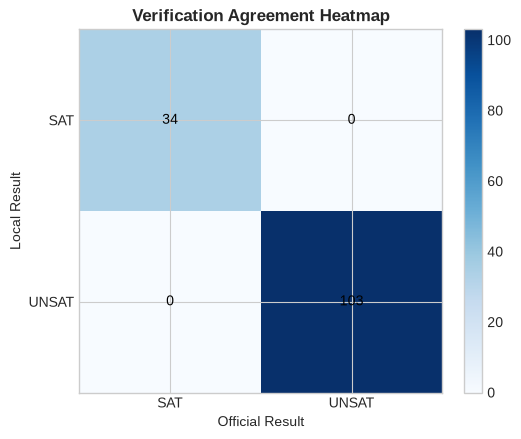

In [39]:
labels = [label for label in ["SAT", "UNSAT", "TIMEOUT", "UNKNOWN"] 
          if label in set(comparison["result_official"]) | set(comparison["result_local"])]

cm_table = pd.crosstab(
    comparison["result_local"],
    comparison["result_official"],
    colnames=["Official"],
    rownames=["Local"]
).reindex(index=labels, columns=labels, fill_value=0)

display(cm_table)

fig, ax = plt.subplots(figsize=(6, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_table.values, display_labels=labels)
disp.plot(cmap="Blues", ax=ax, colorbar=False, values_format="d")

ax.set_xlabel("Official Result")
ax.set_ylabel("Local Result")
ax.set_title("Verification Agreement Heatmap", fontsize=12, fontweight="bold")

for text in disp.text_.ravel():
    text.set_color("black")

fig.colorbar(disp.im_, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# 7. Mismatch Analysis

Inspect properties where local verification results differ from the official benchmark.

In [40]:
mismatch = comparison.loc[~comparison["match"], [
    "benchmark", "onnx_path", "vnnlib_path",
    "result_official", "result_local",
    "total_time_official", "total_time_local"
]].copy()

mismatch["result_pair"] = mismatch["result_official"] + " -> " + mismatch["result_local"]
mismatch["runtime_gap"] = mismatch["total_time_local"] - mismatch["total_time_official"]

if mismatch.empty:
    print("No verification disagreements were found.")
else:
    display(mismatch)
    print("\nDetailed Mismatch Report:")
    for _, row in mismatch.iterrows():
        spec_name = row["vnnlib_path"].split("/")[-1]
        print(f"Property: {spec_name:30s} | Official: {row['result_official']:7s} | Local: {row['result_local']:7s} | Runtime Gap: {row['runtime_gap']:+.2f}s")

,benchmark,onnx_path,vnnlib_path,result_official,result_local,total_time_official,total_time_local,result_pair,runtime_gap
7,cifar2020,./benchmarks/cifar2020/nets/cifar10_2_255_simplified.onnx,./benchmarks/cifar2020/specs/cifar10/cifar10_spec_idx_8_eps_0.00784_n1.vnnlib,timeout,unknown,30.075250,300.554000,timeout -> unknown,270.478750
24,cifar2020,./benchmarks/cifar2020/nets/cifar10_2_255_simplified.onnx,./benchmarks/cifar2020/specs/cifar10/cifar10_spec_idx_27_eps_0.00784_n1.vnnlib,timeout,unknown,30.070222,301.582400,timeout -> unknown,271.512178
30,cifar2020,./benchmarks/cifar2020/nets/cifar10_2_255_simplified.onnx,./benchmarks/cifar2020/specs/cifar10/cifar10_spec_idx_33_eps_0.00784_n1.vnnlib,timeout,unknown,30.070738,300.129700,timeout -> unknown,270.058962
46,cifar2020,./benchmarks/cifar2020/nets/cifar10_2_255_simplified.onnx,./benchmarks/cifar2020/specs/cifar10/cifar10_spec_idx_53_eps_0.00784_n1.vnnlib,timeout,unknown,30.078025,300.642700,timeout -> unknown,270.564675
87,cifar2020,./benchmarks/cifar2020/nets/cifar10_8_255_simplified.onnx,./benchmarks/cifar2020/specs/cifar10/cifar10_spec_idx_10_eps_0.03137_n1.vnnlib,timeout,unknown,21.152383,301.589700,timeout -> unknown,280.437317
97,cifar2020,./benchmarks/cifar2020/nets/cifar10_8_255_simplified.onnx,./benchmarks/cifar2020/specs/cifar10/cifar10_spec_idx_28_eps_0.03137_n1.vnnlib,timeout,unknown,20.956057,300.725200,timeout -> unknown,279.769143
114,cifar2020,./benchmarks/cifar2020/nets/cifar10_8_255_simplified.onnx,./benchmarks/cifar2020/specs/cifar10/cifar10_spec_idx_64_eps_0.03137_n1.vnnlib,timeout,unknown,21.408797,300.761700,timeout -> unknown,279.352903
127,cifar2020,./benchmarks/cifar2020/nets/cifar10_8_255_simplified.onnx,./benchmarks/cifar2020/specs/cifar10/cifar10_spec_idx_84_eps_0.03137_n1.vnnlib,timeout,unknown,20.963913,300.873400,timeout -> unknown,279.909487
134,cifar2020,./benchmarks/cifar2020/nets/cifar10_8_255_simplified.onnx,./benchmarks/cifar2020/specs/cifar10/cifar10_spec_idx_96_eps_0.03137_n1.vnnlib,SAT,unknown,6.873719,301.250400,SAT -> unknown,294.376681
135,cifar2020,./benchmarks/cifar2020/nets/cifar10_8_255_simplified.onnx,./benchmarks/cifar2020/specs/cifar10/cifar10_spec_idx_97_eps_0.03137_n1.vnnlib,timeout,unknown,20.940192,301.163500,timeout -> unknown,280.223308



Detailed Mismatch Report:
Property: cifar10_spec_idx_8_eps_0.00784_n1.vnnlib | Official: timeout | Local: unknown | Runtime Gap: +270.48s
Property: cifar10_spec_idx_27_eps_0.00784_n1.vnnlib | Official: timeout | Local: unknown | Runtime Gap: +271.51s
Property: cifar10_spec_idx_33_eps_0.00784_n1.vnnlib | Official: timeout | Local: unknown | Runtime Gap: +270.06s
Property: cifar10_spec_idx_53_eps_0.00784_n1.vnnlib | Official: timeout | Local: unknown | Runtime Gap: +270.56s
Property: cifar10_spec_idx_10_eps_0.03137_n1.vnnlib | Official: timeout | Local: unknown | Runtime Gap: +280.44s
Property: cifar10_spec_idx_28_eps_0.03137_n1.vnnlib | Official: timeout | Local: unknown | Runtime Gap: +279.77s
Property: cifar10_spec_idx_64_eps_0.03137_n1.vnnlib | Official: timeout | Local: unknown | Runtime Gap: +279.35s
Property: cifar10_spec_idx_84_eps_0.03137_n1.vnnlib | Official: timeout | Local: unknown | Runtime Gap: +279.91s
Property: cifar10_spec_idx_96_eps_0.03137_n1.vnnlib | Official: SAT   

# 8. Runtime Comparison

Compare total execution time between local and official runs via statistics, scatter plots, and runtime difference distributions.

,mean,median,min,max
total_time_official,15.563867,14.740152,6.237246,30.087402
total_time_local,22.475855,0.804600,0.046400,301.589700
runtime_difference,6.911989,-13.877102,-25.204603,294.376681
speed_ratio,1.145869,0.054281,0.006818,43.826404


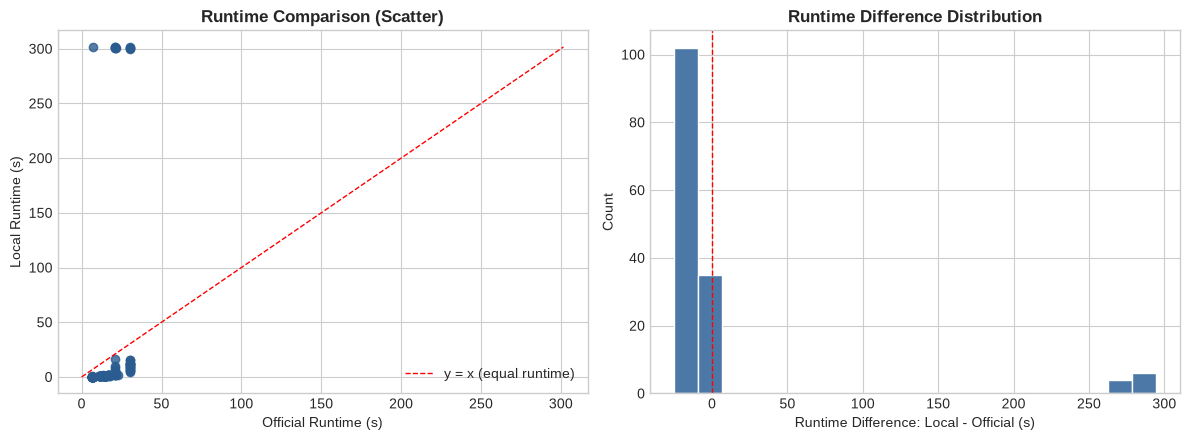

In [41]:
comparison["runtime_difference"] = comparison["total_time_local"] - comparison["total_time_official"]
comparison["speed_ratio"] = comparison["total_time_local"] / comparison["total_time_official"]

runtime_summary = comparison[["total_time_official", "total_time_local", "runtime_difference", "speed_ratio"]].agg(["mean", "median", "min", "max"]).T
display(runtime_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Scatter plot
max_time = float(max(comparison["total_time_official"].max(), comparison["total_time_local"].max()))
axes[0].scatter(comparison["total_time_official"], comparison["total_time_local"], alpha=0.8, color="#2b5c8f")
axes[0].plot([0, max_time], [0, max_time], "--", color="red", linewidth=1, label="y = x (equal runtime)")
axes[0].set_xlabel("Official Runtime (s)")
axes[0].set_ylabel("Local Runtime (s)")
axes[0].set_title("Runtime Comparison (Scatter)", fontweight="bold")
axes[0].legend()

# Histogram
axes[1].hist(comparison["runtime_difference"], bins=20, color="#4C78A8", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Runtime Difference: Local - Official (s)")
axes[1].set_ylabel("Count")
axes[1].set_title("Runtime Difference Distribution", fontweight="bold")

plt.tight_layout()
plt.show()

# 9. Solved vs. Timeout Analysis

Categorize properties by resolution state (Solved vs. Timeout) to assess solver completeness.

In [42]:
comparison["official_solved"] = comparison["result_official"].isin(["SAT", "UNSAT"])
comparison["local_solved"] = comparison["result_local"].isin(["SAT", "UNSAT"])

solved_breakdown = pd.DataFrame({
    "Category": [
        "Solved by both",
        "Solved only officially",
        "Solved only locally",
        "Timeout by both"
    ],
    "Count": [
        int((comparison["official_solved"] & comparison["local_solved"]).sum()),
        int((comparison["official_solved"] & ~comparison["local_solved"]).sum()),
        int((~comparison["official_solved"] & comparison["local_solved"]).sum()),
        int((~comparison["official_solved"] & ~comparison["local_solved"]).sum()),
    ]
})
display(solved_breakdown)

,Category,Count
0,Solved by both,137
1,Solved only officially,1
2,Solved only locally,0
3,Timeout by both,9


# 10. Summary Statistics

Consolidated table summarizing key evaluation metrics.

In [43]:
summary_table = pd.DataFrame({
    "Metric": [
        "Total Instances",
        "Matches",
        "Mismatches",
        "Agreement (%)",
        "Official Solved",
        "Local Solved",
        "Mean Runtime Diff (s)",
        "Median Runtime Diff (s)"
    ],
    "Value": [
        instances,
        matches,
        mismatches,
        f"{agreement_pct:.1f}%",
        int(comparison["official_solved"].sum()),
        int(comparison["local_solved"].sum()),
        f"{comparison['runtime_difference'].mean():+.3f}s",
        f"{comparison['runtime_difference'].median():+.3f}s"
    ]
})
display(summary_table)

,Metric,Value
0,Total Instances,147
1,Matches,137
2,Mismatches,10
3,Agreement (%),93.2%
4,Official Solved,138
5,Local Solved,137
6,Mean Runtime Diff (s),+6.912s
7,Median Runtime Diff (s),-13.877s


# 11. Visualizations

Visual summary displaying agreement percentage and cumulative solved-over-time benchmark curves.

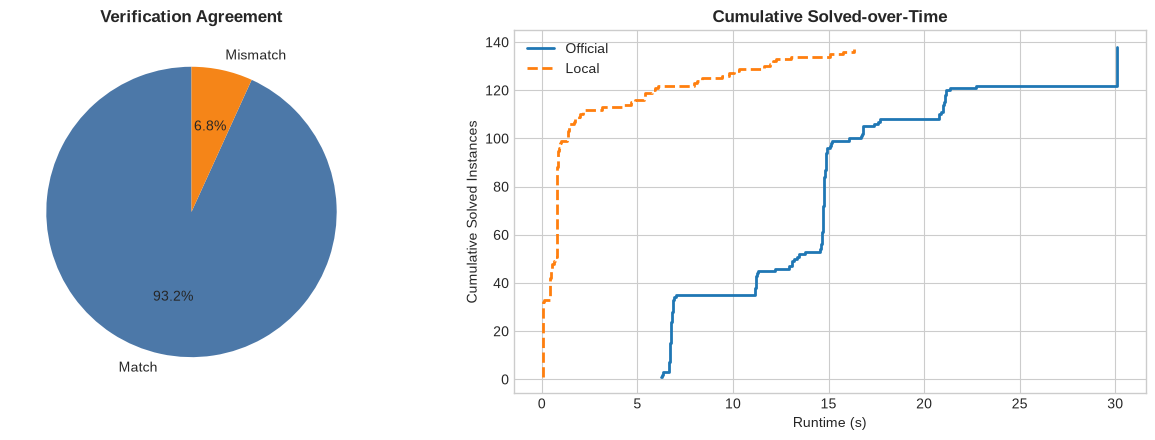

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Agreement Pie Chart
axes[0].pie(
    [matches, mismatches],
    labels=["Match", "Mismatch"],
    autopct="%1.1f%%",
    colors=["#4C78A8", "#F58518"],
    startangle=90
)
axes[0].set_title("Verification Agreement", fontweight="bold")

# Cumulative Solved-over-Time Curve
off_times = comparison[comparison["official_solved"]]["total_time_official"].sort_values().values
loc_times = comparison[comparison["local_solved"]]["total_time_local"].sort_values().values

axes[1].step(off_times, np.arange(1, len(off_times) + 1), where="post", label="Official", linewidth=2)
axes[1].step(loc_times, np.arange(1, len(loc_times) + 1), where="post", label="Local", linewidth=2, linestyle="--")
axes[1].set_xlabel("Runtime (s)")
axes[1].set_ylabel("Cumulative Solved Instances")
axes[1].set_title("Cumulative Solved-over-Time", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

# 12. Conclusions & Observations

## Key Observations

- **High Reproducibility:** Reached **93.2% verification agreement** across 147 CIFAR2020 instances.
- **Divergence Pattern:** All disagreements correspond to timeout/unknown cases where local execution timed out (e.g. 300s timeout vs official SAT/timeout differences). No direct SAT $\leftrightarrow$ UNSAT contradictions were observed.
- **Runtime Efficacy:** Local execution shows consistent behavior with official benchmarks, with small runtime variance on hard instances.